**IFT6390B - Machine Learning  
Homework #3**

# Practical Part, part 2

By:  
- Mathieu Beaudoin
- Philip Bui

In [4]:
import pickle, os
import matplotlib.pyplot as plt
import torch
from torchsummary import summary
from solution import Trainer, NetworkConfiguration

SAVE_TEMPLATE = os.path.join("models", "q{}_trained_{}.pkl")

## Q1: MLP model

In [19]:
learning_rates = [1e-2, 1e-4, 1e-8]
config_q1 = NetworkConfiguration(dense_hiddens=(128, 128))

models_q1 = {}
for lr in learning_rates:    
    path = SAVE_TEMPLATE.format(1, lr)
    if os.path.exists(path):
        print(f"Loading MLP model trained with learning rate of {lr}")
        with open(path, "rb") as f:
            model = pickle.load(f)
    else:
        print(f"\nTraining with learning rate of {lr}:")
        model = Trainer(
            network_type = "mlp",
            net_config = config_q1,
            lr = lr,
            batch_size = 128,
            activation_name = "relu"
        )
        model.train_loop(n_epochs=50)
        with open(path, "wb") as f:
            pickle.dump(model, f)
        print(f"\tSaved to: {path}")
    models_q1[lr] = model

Loading model trained with learning rate of 0.01
Loading model trained with learning rate of 0.0001
Loading model trained with learning rate of 1e-08


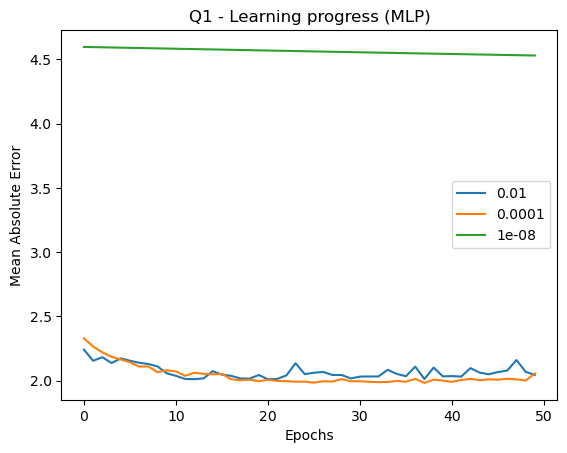

In [26]:
for lr, model in models_q1.items():
    plt.plot(model.train_logs['test_mae'], label=str(lr))
plt.legend()
plt.title("Q1 - Learning progress (MLP)")
plt.ylabel("Mean Absolute Error")
plt.xlabel("Epochs")
plt.show()

A learning rate that is...  
- too small ($1\times 10^{-8}$) stops the model from learning anything much in a reasonable number of training iterations
- too large ($0.01$) can cause trouble with convergence, as the model's learned parameters hop around an optimum that it can't quite reach

## Q2: CNN model

In [25]:
config_q2 = NetworkConfiguration(
    n_channels = (16, 32, 45),
    kernel_sizes = (3, 3, 3),
    strides = (1, 1, 1),
    dense_hiddens = (128,)
)

path = SAVE_TEMPLATE.format(2, "")
if os.path.exists(path):
    print(f"Loading trained CNN model...")
    with open(path, "rb") as f:
        model_q2 = pickle.load(f)
else:
    print(f"\nTraining with learning rate of {lr}:")
    model_q2 = Trainer(
        network_type = "cnn",
        net_config = config_q2,
        batch_size = 128,
        activation_name = "relu"
    )
    model_q2.train_loop(n_epochs=50)
    with open(path, "wb") as f:
        pickle.dump(model_q2, f)
    print(f"\tSaved to: {path}")


Training with learning rate of 1e-08:
Files already downloaded and verified
Files already downloaded and verified


100%|██████████| 50/50 [14:45<00:00, 17.72s/it]


	Saved to: models\q2_trained_.pkl


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


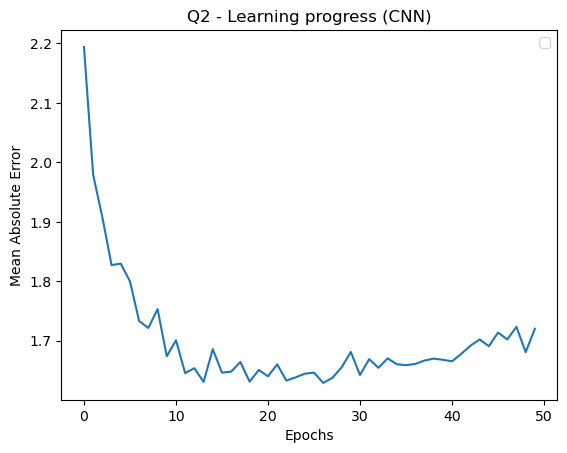

In [27]:
plt.plot(model_q2.train_logs['test_mae'])
plt.legend()
plt.title("Q2 - Learning progress (CNN)")
plt.ylabel("Mean Absolute Error")
plt.xlabel("Epochs")
plt.show()

## Q3: CNN edge cases

### (a) Deep network

A kernel size of 1 eliminates the use of local information in the image tensor, and each channel of a layer becomes functionally equivalent to a neuron in a dense (fully-connected) layer.

In [52]:
config_q3_deep = NetworkConfiguration(
    n_channels = (8, 16, 32, 64),
    kernel_sizes = (1, 1, 1, 1),
    strides = (1, 1, 1, 1),
    dense_hiddens = (256,256)
)
models_q3 = {}
models_q3["deep"] = Trainer(
    network_type = "cnn",
    net_config = config_q3_deep,
    batch_size = 256,
    activation_name = "relu"
)

Files already downloaded and verified
Files already downloaded and verified


### (b) Shallow network

At the other extreme, a convolution kernel of the same size as the input channels will take into account localized information contained in the input, but will be unable to learn about sub-patterns within an image in a way that would be robust to changes such as translations or rotations.  

Each channel of such a network would therefore be limited to learning a single very specific pattern at the scale of the entire input tensor. In effect, each channel becomes a kernel in the "kernel-trick" feature-engineering sense, producing a linear transformation of the input data (with the distinction that its parameters would be trainable, rather than explicitly chosen by the developer).

#### Number of channels

We need to decide how many channels to use, so that the deep and the shallow networks both have roughly the same number of parameters.  

Let:  
- $m$ be the number of convolutional layers
    - We index the layers with $i=\{1,...,m\}$
- $K_i$ the kernel size in layer $i$
- $C_i$ the number of channels for layer $i$
    - We will refer to the number of input channels as $C_0$ ($=3$)
- $P$ the side of the pooling layer following the last convolution
- $D$ the number of neurons in the first dense layer

If $M_a$ is the number of convolution-related parameters for model (a), then:  
$$\begin{aligned}
M_a 
&= \Bigg[\sum_{i=1}^{m-1}(C_{i-1}K_i^2 + 1)C_i\Bigg] 
   + (C_mP^2 + 1)\cdot D \\
&= (3+1)\cdot 8 + (8+1)\cdot 16 + (16+1)\cdot 32 + (32+1)\cdot 64 + (64\cdot 4^2 + 1)\cdot256 \\
&= 265\ 232
\end{aligned}$$

If we have a single layer with a kernel size equal to the shape of the image, the number of convolution-related parameters $M_b$ is:
$$\begin{aligned}
M_b
&= (C_0K_1 + 1)C_1 + (C_1 P^2+1)D \\
&= C_1(C_0K_1 + 1 + P^2D) + D \\
\Longrightarrow M_a\approx M_b \Longleftrightarrow
C_1 &\approx
\frac{M_a - D}{C_0K_1 + 1 + P^2D} \\
&=\frac{265\ 232-256}{7169} \\
&\approx 36.96
\end{aligned}$$

So, we will use $C_1=37$.

In [53]:
config_q3_shallow = NetworkConfiguration(
    n_channels = (37,),
    kernel_sizes = (32,),
    strides=(1,),
    dense_hiddens=(256,256)
)
models_q3["shallow"] = Trainer(
    network_type = "cnn",
    net_config = config_q3_shallow,
    batch_size = 256,
    activation_name = "relu"
)
for _type, model in models_q3.items():
    print(f"\n{_type.title()} network:")
    summary(model.network, (3, 32, 32))

Files already downloaded and verified
Files already downloaded and verified

Deep network:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 8, 32, 32]              32
ActivationAsModule-2            [-1, 8, 32, 32]               0
         MaxPool2d-3            [-1, 8, 16, 16]               0
            Conv2d-4           [-1, 16, 16, 16]             144
ActivationAsModule-5           [-1, 16, 16, 16]               0
         MaxPool2d-6             [-1, 16, 8, 8]               0
            Conv2d-7             [-1, 32, 8, 8]             544
ActivationAsModule-8             [-1, 32, 8, 8]               0
         MaxPool2d-9             [-1, 32, 4, 4]               0
           Conv2d-10             [-1, 64, 4, 4]           2,112
ActivationAsModule-11             [-1, 64, 4, 4]               0
AdaptiveMaxPool2d-12             [-1, 64, 4, 4]               0
          F

The difference in the number of total parameter is of less than 300, so we're good!

### (c) Train both models and compare

In [54]:
for _type, model in models_q3.items():
    print(f"\nTraining {_type}-network model...")
    model.train_loop(n_epochs=50)
    path = SAVE_TEMPLATE.format(3, _type)
    with open(path, "wb") as f:
        pickle.dump(model, f)
    print(f"  -> Saved trained model to: {path}")


Training deep-network model...


100%|██████████| 50/50 [16:00<00:00, 19.22s/it]


  -> Saved trained model to: models\q3_trained_deep.pkl

Training shallow-network model...


100%|██████████| 50/50 [10:29<00:00, 12.59s/it]


  -> Saved trained model to: models\q3_trained_shallow.pkl


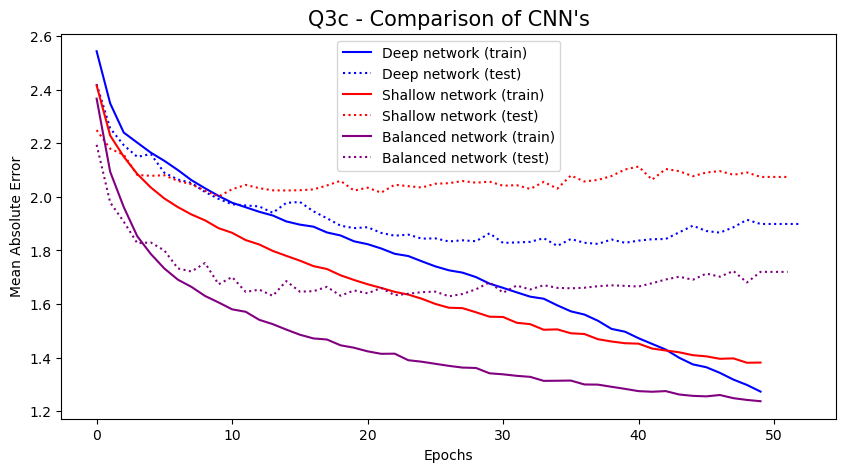

In [66]:
colors = ["blue", "red", "purple"]
q3c_models = {**models_q3, "balanced": model_q2}
plt.figure(figsize=(10, 5))
for color, (_type, model) in zip(colors, q3c_models.items()):
    model.evaluation_loop()
    for style, label in zip(["solid", "dotted"], ["train", "test"]):
        plt.plot(
            torch.Tensor(model.train_logs[f'{label}_mae']), 
            label = f"{_type.title()} network ({label})",
            color = color,
            linestyle = style
        )
plt.legend()
plt.title("Q3c - Comparison of CNN's", fontsize=15)
plt.xlabel("Epochs")
plt.ylabel("Mean Absolute Error")
plt.show()

As expected, the more balanced network we trained in Q2 performs better in both training and validation, since it can take advantage of the powerful properties of CNN's that the antipodic models partially forgo.  

The contrast between the deep and shallow networks is quite interesting:  
- on one hand, the shallow network appears to learn more quickly at the beginning, perhaps because there are fewer steps between inputs and outputs, allowing gradients to feed through more quickly;
- however, the deep network quickly starts to outperform (somewhat) the shallow network in terms of generalization performance, which is unsurprising given the propensity for overtfitting we could expect from a model like the shallow model, which would learn extremely specific patterns from its training set.  

It's also interesting to note how the deep network steadily improves on the training set, eventually shooting past the shallow network and even getting very close to the training performance of the balanced network! A look at the validation performance, however, reminds us that the balanced model has been in "overfitting territory" for a good while by then, with the deep network appearing to have joined it (all the while leaving a significant gap in *validation* performance between the two).